# [LAB 11] 4. 시계열의 통계적 접근
## 연습문제
![alt text](image-32.png)

In [19]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from pandas import DataFrame

In [4]:
origin = load_data('temperatures_seoul')
df = my_ts.set_index(origin, '날짜', freq='MS')
print(f'데이터셋 크기: {df.shape[0]}행 | 인덱스 가격: {df.index.freqstr}')
df.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
데이터셋 크기: 602행 | 인덱스 가격: MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


계절 주기 확인 및 분해 

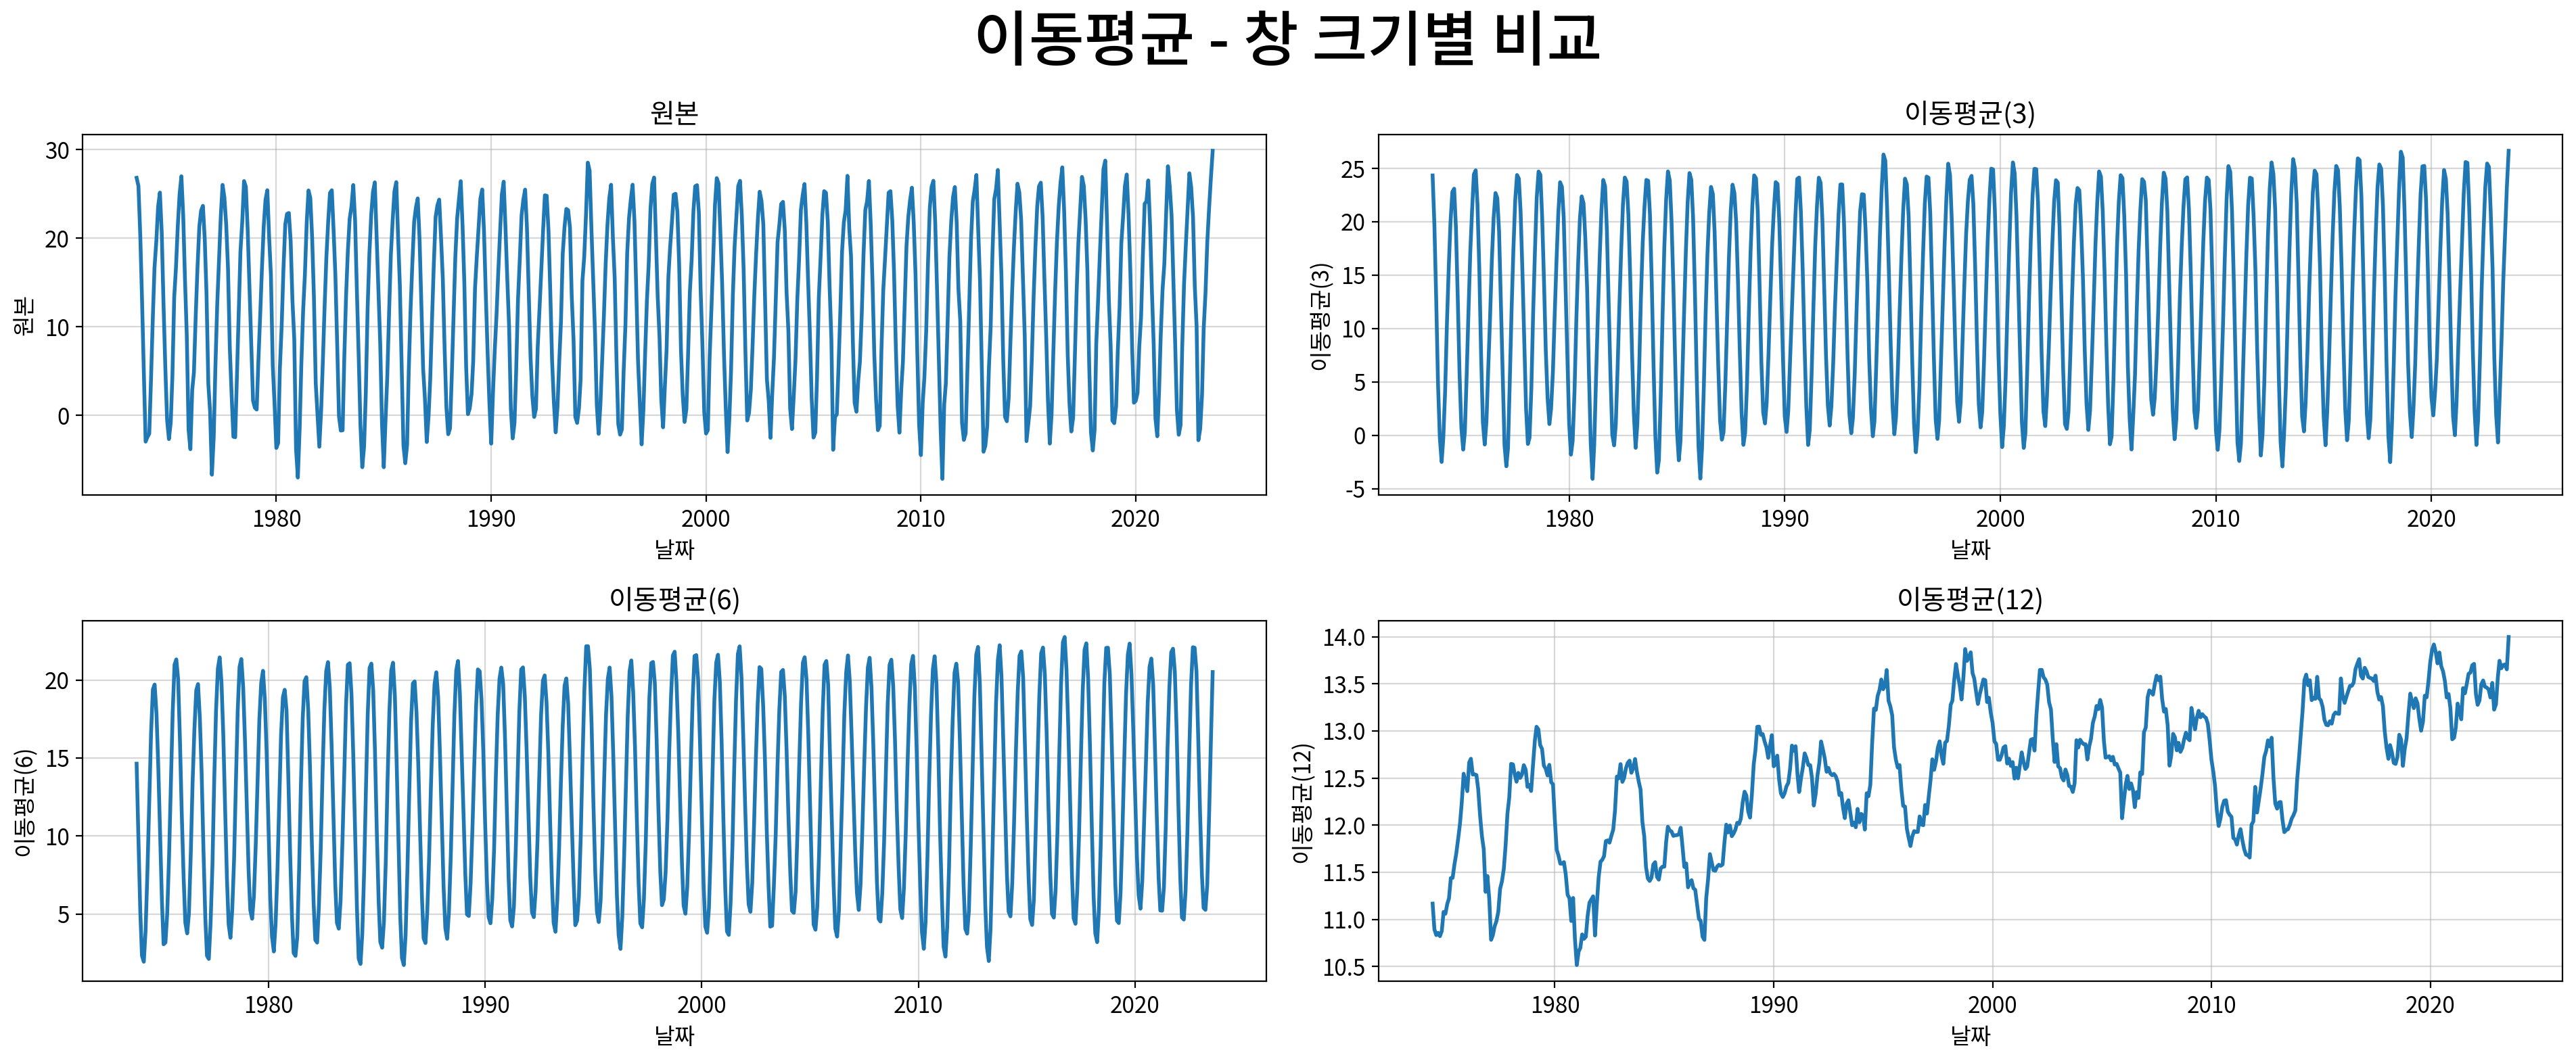

In [16]:
ma_result = my_ts.compare_smoothing(df, (3,6,12), '평균기온(℃)', method='ma', title='이동평균 - 창 크기별 비교')

In [21]:
std_result = DataFrame({'표준편차': ma_result.std()})
std_result

,표준편차
원본,9.932
이동평균(3),8.970
이동평균(6),6.332
이동평균(12),0.745


결합 방식 자동 판정: additive
관측치 602개 중 추세·잔차가 계산된 구간 590개


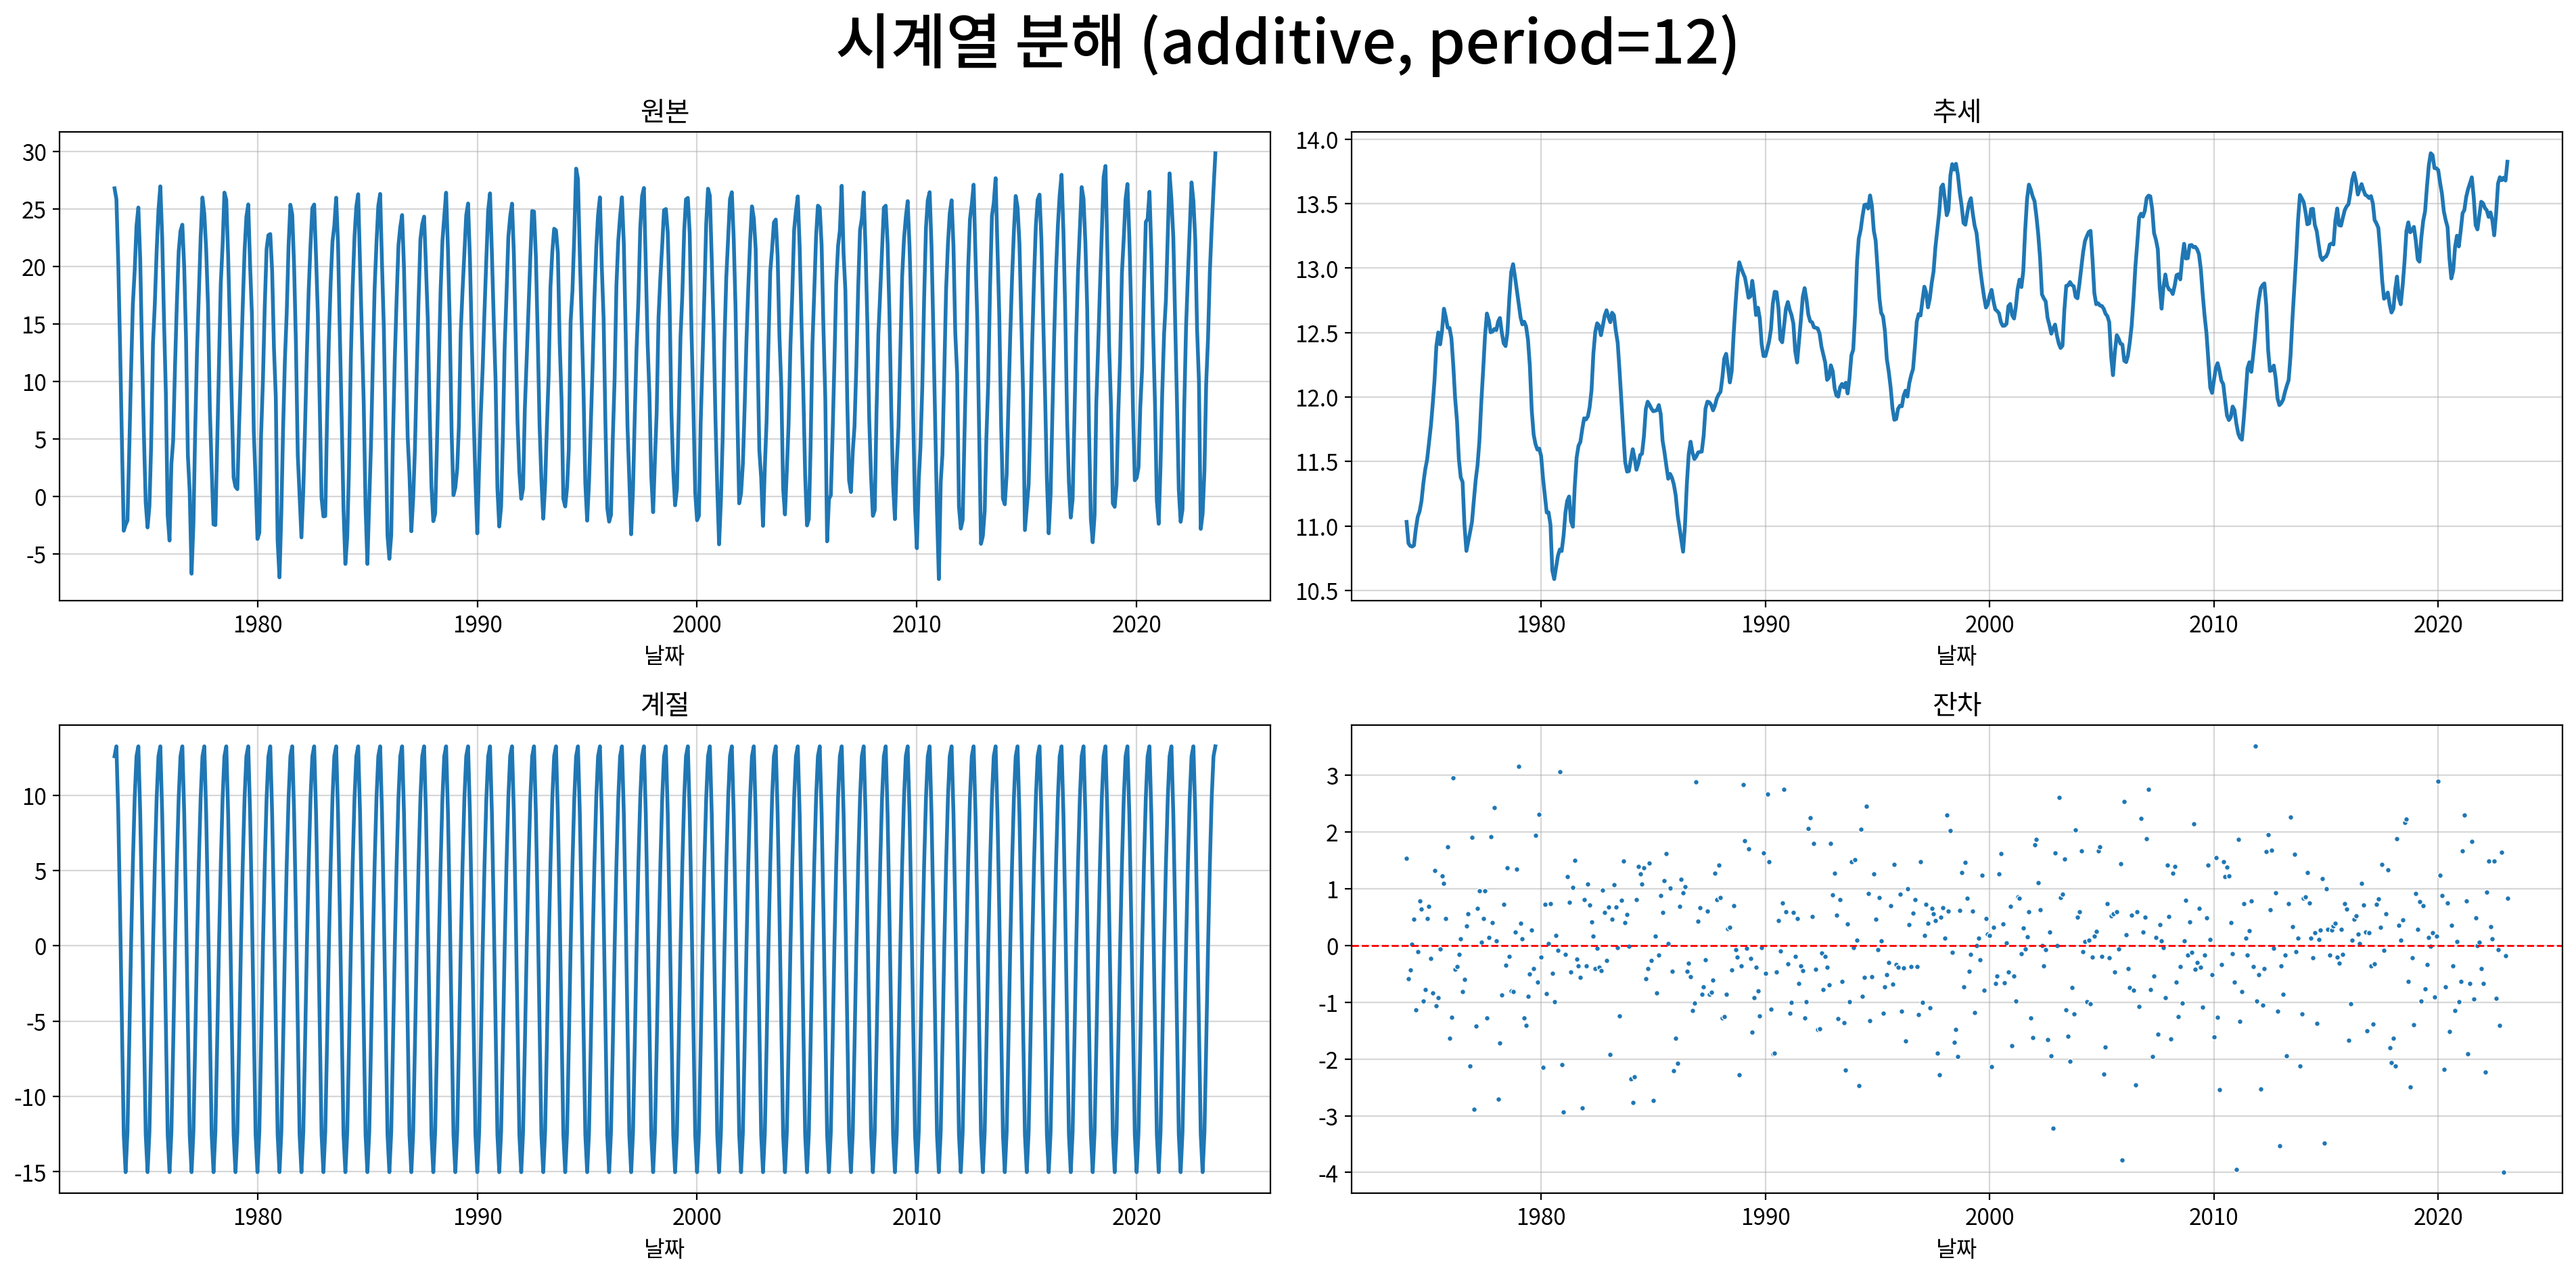

,원본,추세,계절,잔차
날짜,,,,
1974-01-01,-2.458,11.031,-15.024,1.535
1974-02-01,-2.079,10.864,-12.361,-0.582
1974-03-01,3.687,10.845,-6.728,-0.430
1974-04-01,10.720,10.840,-0.136,0.016
1974-05-01,16.665,10.849,5.360,0.456
...,...,...,...,...
2022-10-01,14.565,13.705,2.273,-1.414
2022-11-01,10.030,13.682,-5.288,1.635
2022-12-01,-2.816,13.702,-12.524,-3.994


In [32]:
result1 = my_ts.decompose(df, 12, "평균기온(℃)")
result1.dropna()

차분

In [40]:
my_ts.adf_diff(df, '평균기온(℃)')

3차 차분에서 표준편차가 다시 커져 중단했습니다. (과대차분 시작)
권장 차분 차수: 2차 차분 (표준편차가 최소인 지점)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정,권장
원본,602,-3.877,0.002,14,-3.442,-2.866,-2.569,9.932,True,정상,
1차 차분,601,-10.529,0.000,13,-3.442,-2.866,-2.569,5.407,True,정상,
2차 차분,600,-13.340,0.000,18,-3.442,-2.867,-2.569,3.982,True,정상,★ 여기까지
3차 차분,599,-18.990,0.000,19,-3.442,-2.867,-2.569,5.402,True,정상,과대차분


In [44]:
stationary = my_ts.adf_transform(df, '평균기온(℃)', period=12, max_diff=2, log=False)
my_ts.adf_test(stationary)

조합 6개 중 정상 6개
권장 전처리: 계절차분(12)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
계절차분(12),590,-8.829,0.000,12,-3.442,-2.867,-2.569,1.881,True,정상
1차 차분 + 계절차분(12),589,-10.251,0.000,19,-3.442,-2.867,-2.569,2.371,True,정상
2차 차분,600,-13.340,0.000,18,-3.442,-2.867,-2.569,3.982,True,정상
2차 차분 + 계절차분(12),588,-10.171,0.000,19,-3.442,-2.867,-2.569,4.010,True,정상
1차 차분,601,-10.529,0.000,13,-3.442,-2.866,-2.569,5.407,True,정상
원본,602,-3.877,0.002,14,-3.442,-2.866,-2.569,9.932,True,정상


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
계절차분(12),590,-8.829,0.000,12,-3.442,-2.867,-2.569,1.881,True,정상


관측치 590개 | 유의성 기준값 0.082 | 최대 시차 36 (상한 N/4=147)
AR 차수 후보 (p): 1   ← PACF가 lag 1 이후 절단
MA 차수 후보 (q): 3   ← ACF가 lag 3 이후 절단
계절 AR 차수 후보 (P): 3   ← 계절 PACF가 lag 36 이후 절단 (판정 시차 [12, 24, 36])
계절 MA 차수 후보 (Q): 2   ← 계절 ACF가 lag 24 이후 절단 (판정 시차 [12, 24, 36])
→ SARIMA(1, d, 3)(3, D, 2)[12] — d·D 는 차분 단계의 결과를 넣는다


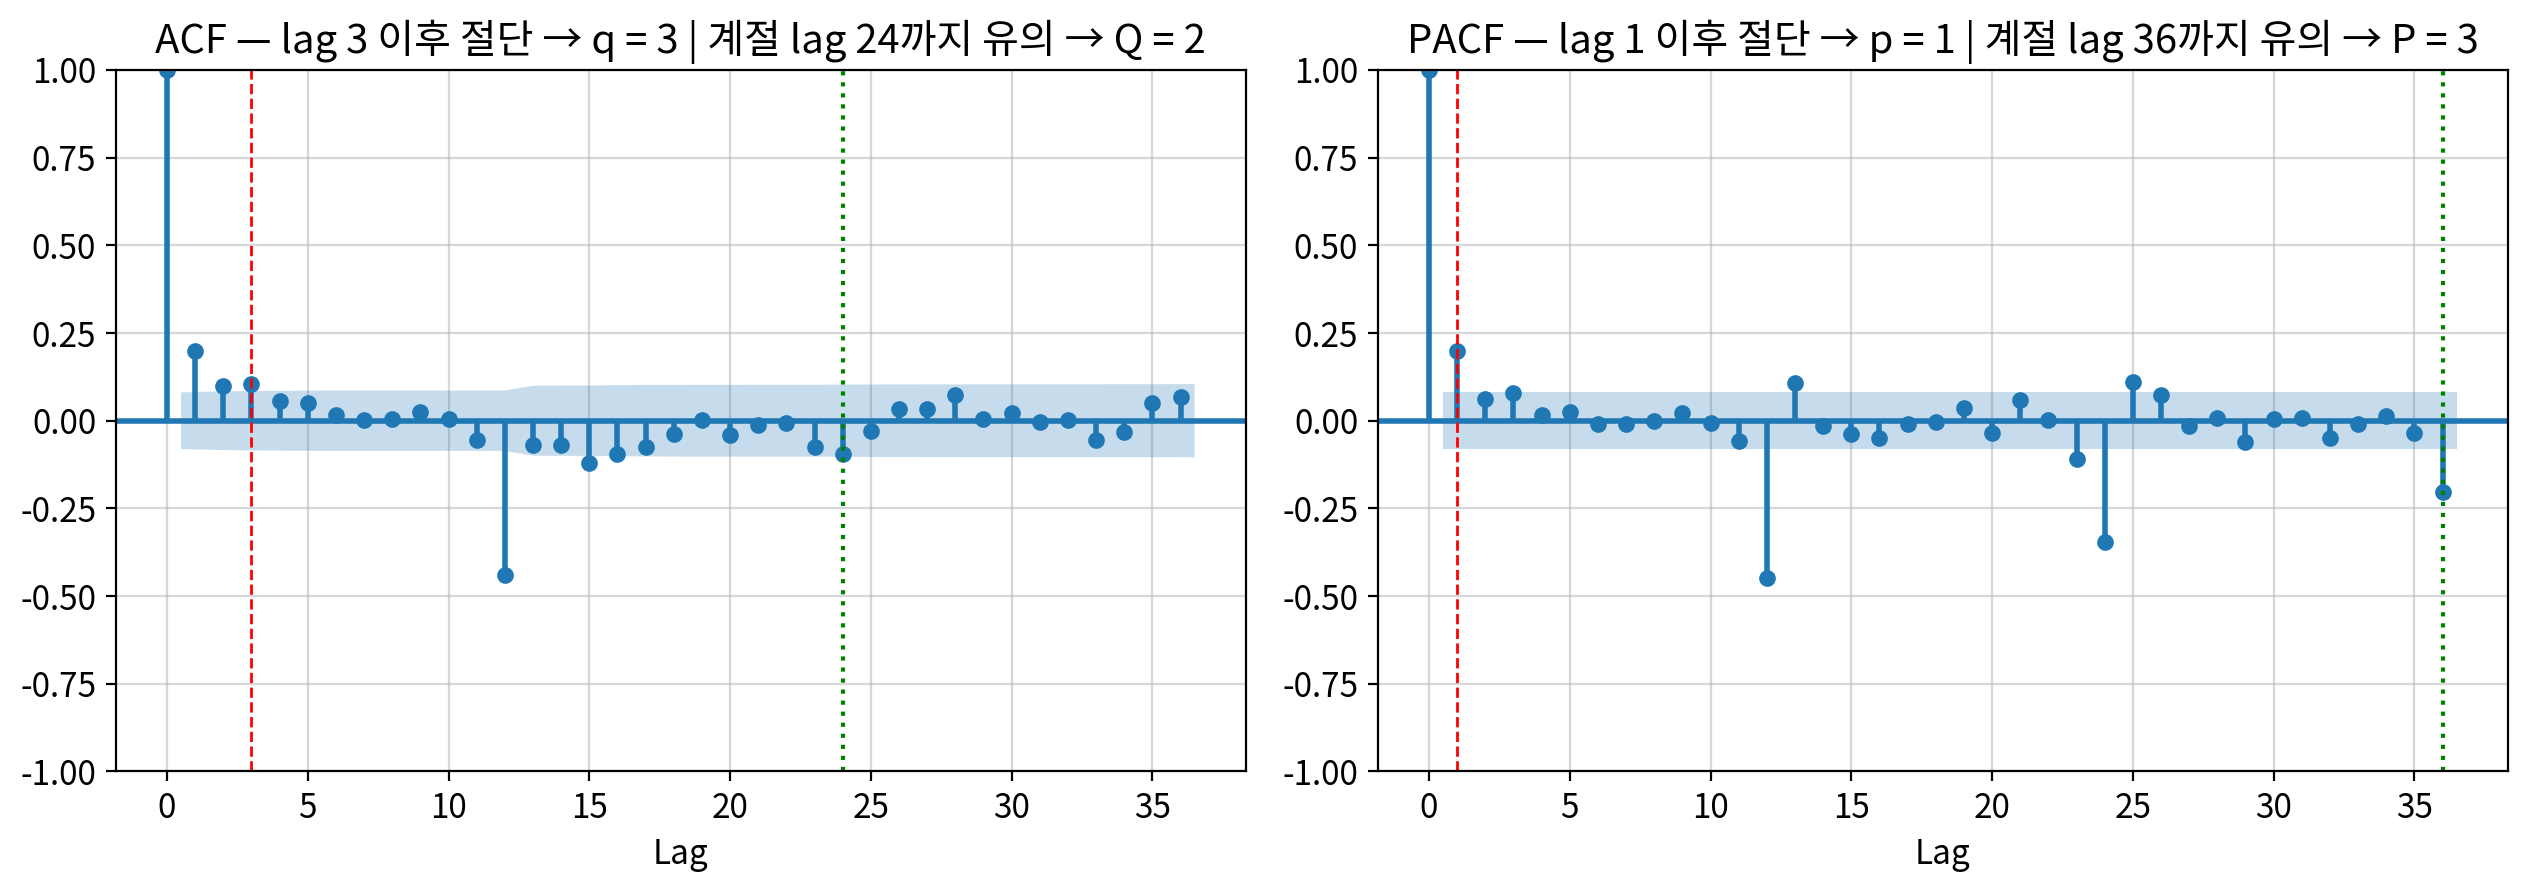

,acf,acf 유의성,pacf,pacf 유의성,기준값,p,q,P,Q
lag,,,,,,,,,
1,0.200,True,0.200,True,0.082,◀,,,
2,0.099,True,0.061,False,0.082,,,,
3,0.105,True,0.078,False,0.082,,◀,,
4,0.056,False,0.018,False,0.082,,,,
5,0.051,False,0.026,False,0.082,,,,
6,0.017,False,-0.009,False,0.082,,,,
7,0.002,False,-0.010,False,0.082,,,,
8,0.005,False,-0.001,False,0.082,,,,
9,0.025,False,0.024,False,0.082,,,,


In [45]:
my_ts.auto_correlation(stationary, period=12, rows=1, cols=2, width=640, height=480)

- 문제 1. 12
- 문제 2. 가법
- 문제 3. 590개
- 문제 4. q=3
- 문제 5. p=1
- 문제 6. Q=2, P=3